In [1]:
import os

import ipywidgets as widgets
import matplotlib
import numpy as np
import scipy.io as spio
from cil.framework import AcquisitionData, AcquisitionGeometry
from cil.io import TIFFStackReader
from cil.recon import FBP, FDK
from cil.utilities.display import show2D
from gvxrPython3 import gvxr
from gvxrPython3.utils import applyFiltration, loadSpectrum
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

# Configure matplotlib graph
font = {
    "family" : "serif",
    "size"   : 15,
}
matplotlib.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


In [2]:
gvxr.useLogFile("beam-hardening.log")

### Global variables

In [3]:
INPUT_PATH = "../../../data/HelsinkiTomoChallenge"
OUTPUT_PATH = "../../output_data/beam-hardening/"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

In [4]:
def loadmat(filename):
    '''Loads .mat file.

    This function should be called instead of direct spio.loadmat as it
    cures the problem of not properly recovering python dictionaries from
    mat files.
    
    It calls the function ``_check_keys()`` to cure all entries which are
    still mat-objects.
    '''

    data = spio.loadmat(
        filename,
        struct_as_record=False,
        squeeze_me=True
    )
    
    return _check_keys(data)


def _check_keys(dict):  
    '''Checks if entries in dictionary are mat-objects.
    
    If yes, ``todict()`` is called to change them to nested dictionaries.
    '''

    for key in dict: 
        if isinstance(dict[key], spio.matlab.mat_struct):
            dict[key] = _todict(dict[key])

    return dict


def _todict(matobj):
    '''Constructs from matobjects nested dictionaries.'''

    dict = {}

    for strg in matobj._fieldnames:
        elem = matobj.__dict__[strg]
        if isinstance(elem, spio.matlab.mat_struct):
            dict[strg] = _todict(elem)
        else:
            dict[strg] = elem

    return dict


def load_htc2022data(filename, dataset_name="CtDataFull"):
    """Creates Acquisition Data from loaded mat file."""

    # Read in matlab file
    mat = loadmat(filename)
    scan_parameters = mat[dataset_name]["parameters"]

    # Read important parameters
    source_center = scan_parameters["distanceSourceOrigin"]
    source_detector = scan_parameters["distanceSourceDetector"]
    pixel_size = scan_parameters["pixelSizePost"] # Data is binned
    num_dets = scan_parameters["numDetectorsPost"]
    angles = scan_parameters["angles"]

    # Create CIL data from meta data
    ag = AcquisitionGeometry.create_Cone2D(
        source_position=[0,-source_center],
        detector_position=[0,source_detector-source_center],
        ).set_panel(
            num_pixels=num_dets,
            pixel_size=pixel_size,
        ).set_angles(
            angles=-angles,
            angle_unit="degree",
        )

    # Read data
    scan_sinogram = mat[dataset_name]["sinogram"].astype("float32")

    # Create CIL data
    return AcquisitionData(np.squeeze(scan_sinogram), geometry=ag)


def correct_normalisation(data):
    data_intensity = -data
    data_intensity.exp(out = data_intensity)

    counts, bins = np.histogram(
        data_intensity.as_array().ravel(),
        bins=256,
        range=(0.9,1.1)
        )

    index = np.argmax(counts)
    peak_value = bins[index]

    data_intensity_fix = data_intensity / peak_value # Renormalise to set peak to 1
    data_new = data_intensity_fix.log()

    return -data_new

In [5]:
data_path = os.path.join(INPUT_PATH, "htc2022_ta_full.mat")

data_scan_parameters = loadmat(data_path)["CtDataFull"]["parameters"]

# Configure settings
To ensure the gVXR simulations match the experimental parameters, configure the settings provided.

In this case, the .mat file is extensive enough to cover most of the required data but in the case where the information is not available in the file, the parameters should be input (see `tube_angle_degrees`).

Most importantly, include the material of the sample that most closely resembles the material of the sample being scanned. In the case of the HTC data, this material was Aluminium.

In [6]:
material_of_sample = "Al"

# ---------------------------------------------------------------
# Geometry specific values
# ---------------------------------------------------------------
geometry = str(data_scan_parameters["geometryType"])
magnification = float(data_scan_parameters["geometricMagnification"])

# ---------------------------------------------------------------
# Distance values
# ---------------------------------------------------------------
source_detector_distance = float(data_scan_parameters["distanceSourceDetector"])
source_origin_distance = float(data_scan_parameters["distanceSourceOrigin"])
detector_origin_distance = source_detector_distance - source_origin_distance

# ---------------------------------------------------------------
# Units
# ---------------------------------------------------------------
unit_of_length = str(data_scan_parameters["distanceUnit"])
exposure_time_unit = str(data_scan_parameters["exposureTimeUnit"])
tube_voltage_unit = str(data_scan_parameters["voltageUnit"])
tube_current_unit = str(data_scan_parameters["currentUnit"])

# ---------------------------------------------------------------
# Detector Characteristics
# ---------------------------------------------------------------
detector_rows, detector_columns = (
    int(data_scan_parameters["detectorRows"]),
    int(data_scan_parameters["detectorCols"]),
)

pixel_size = float(data_scan_parameters["pixelSizePost"])

# ---------------------------------------------------------------
# Source Characteristics
# ---------------------------------------------------------------
target_material = str(data_scan_parameters["target"])
tube_voltage_kV = float(data_scan_parameters["voltage"])
tube_angle_degrees = float(12)
tube_current = float(data_scan_parameters["current"])

exposure_time = float(data_scan_parameters["exposureTime"])

# ---------------------------------------------------------------
# Filter Characteristics
# ---------------------------------------------------------------
filter_material = str(data_scan_parameters["xRayFilter"])
filter_thickness = float(data_scan_parameters["xRayFilterThickness"])
filter_unit = unit_of_length

print(
f"""
---------------------------------------------------------------
Table of extracted data from the input file
---------------------------------------------------------------
| Detector                  | {data_scan_parameters["detector"]}
| Tube                      | {data_scan_parameters["tube"]}
| Geometry                  | {geometry}
---------------------------------------------------------------
Distances
---------------------------------------------------------------
| Source-Origin distance    | {source_origin_distance} {unit_of_length}
| Detector-Origin distance  | {detector_origin_distance} {unit_of_length}
| Magnification             | {magnification}
---------------------------------------------------------------
Detector Characteristics
---------------------------------------------------------------
| Number of pixels          | {detector_rows}x{detector_columns}
| Pixel size (post-binning) | {pixel_size} {unit_of_length}
---------------------------------------------------------------
Source Characteristics
---------------------------------------------------------------
| Target Material           | {target_material}
| Exposure time             | {exposure_time} {exposure_time_unit}
| Tube Voltage              | {tube_voltage_kV} {tube_voltage_unit}
| Tube Current              | {tube_current} {tube_current_unit}
| Tube Angle (degrees)      | {tube_angle_degrees}
---------------------------------------------------------------
Filter Characteristics
---------------------------------------------------------------
| Filter Material           | {filter_material}
| Filter Thickness          | {filter_thickness} {unit_of_length}
---------------------------------------------------------------
"""
)



---------------------------------------------------------------
Table of extracted data from the input file
---------------------------------------------------------------
| Detector                  | Hamamatsu Photonics C7942CA-22
| Tube                      | Oxford Instruments XTF5011
| Geometry                  | Cone
---------------------------------------------------------------
Distances
---------------------------------------------------------------
| Source-Origin distance    | 410.66 mm
| Detector-Origin distance  | 143.07999999999998 mm
| Magnification             | 1.348414746992646
---------------------------------------------------------------
Detector Characteristics
---------------------------------------------------------------
| Number of pixels          | 2368x2240
| Pixel size (post-binning) | 0.2 mm
---------------------------------------------------------------
Source Characteristics
---------------------------------------------------------------
| Target Materi

### Create an OpenGL context

In [7]:
gvxr.createOpenGLContext()

pci id for fd 87: 10de:1eb1, driver (null)
pci id for fd 88: 10de:1eb1, driver (null)
pci id for fd 87: 10de:1eb1, driver (null)
pci id for fd 88: 10de:1eb1, driver (null)
pci id for fd 87: 10de:1eb1, driver (null)
pci id for fd 88: 10de:1eb1, driver (null)
pci id for fd 87: 10de:1eb1, driver (null)
pci id for fd 88: 10de:1eb1, driver (null)


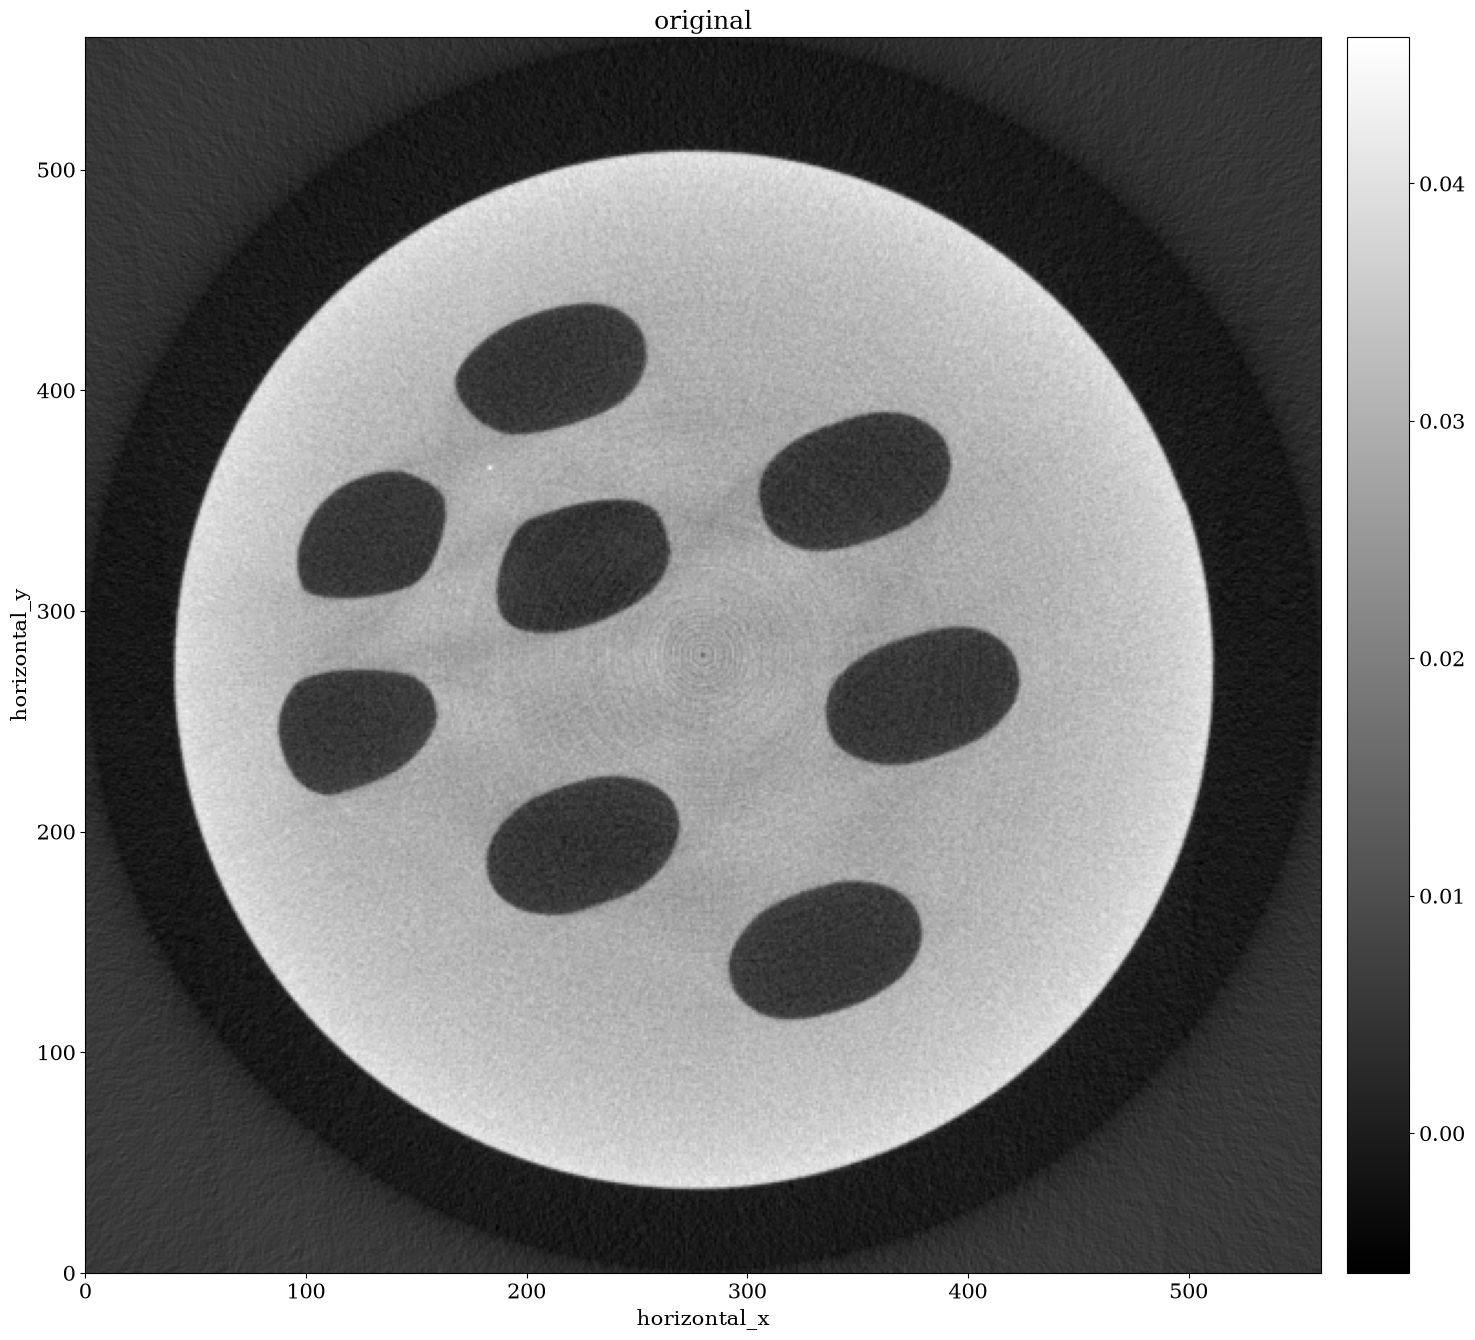

In [8]:
data = load_htc2022data(data_path)
data = correct_normalisation(data)

recon1 = FDK(data).run(verbose=0)

show2D(
    recon1,
    title='original',
    fix_range=True,
)

## Add the line profile for this image (vertical)

###  Set up the detector

In [9]:
source_position = (-source_origin_distance, 0, 0)
detector_position = (detector_origin_distance, 0, 0)
detector_up_vector = (0, 0, -1)

# Detector Position and direction
gvxr.setDetectorPosition(*detector_position, unit_of_length)
gvxr.setDetectorUpVector(*detector_up_vector)

gvxr.setDetectorNumberOfPixels(detector_columns, detector_rows)
gvxr.setDetectorPixelSize(pixel_size, pixel_size, unit_of_length)

In [10]:
def setPolySpectrum(
        tube_voltage_kV: float,
        filters=None,
        tube_angle_in_deg: float=12,
        mAs = None,
        unit = "keV",
) -> dict:

    gvxr.clearFiltration()
    gvxr.setVoltage(tube_voltage_kV, "kV")
    gvxr.setTubeAngle(tube_angle_in_deg)

    if mAs:
        gvxr.setmAs(mAs)
    else:
        gvxr.setmAs(-1)

    if filters:
        applyFiltration(filters)

    energy_bins = gvxr.getEnergyBins(unit)

    photon_count = np.array(
        gvxr.getPhotonCountsPerCm2At1m(),
        dtype=np.single
    )

    photon_count /= (photon_count*energy_bins).sum()

    return loadSpectrum(energy_bins, photon_count, unit, False)

### Create an X-ray source

In [11]:
# Source position
gvxr.setSourcePosition(
    *source_position,
    unit_of_length,
)


# Source type
gvxr.usePointSource()

### Make the source polychromatic

13.977297702298028 13.977297702298028


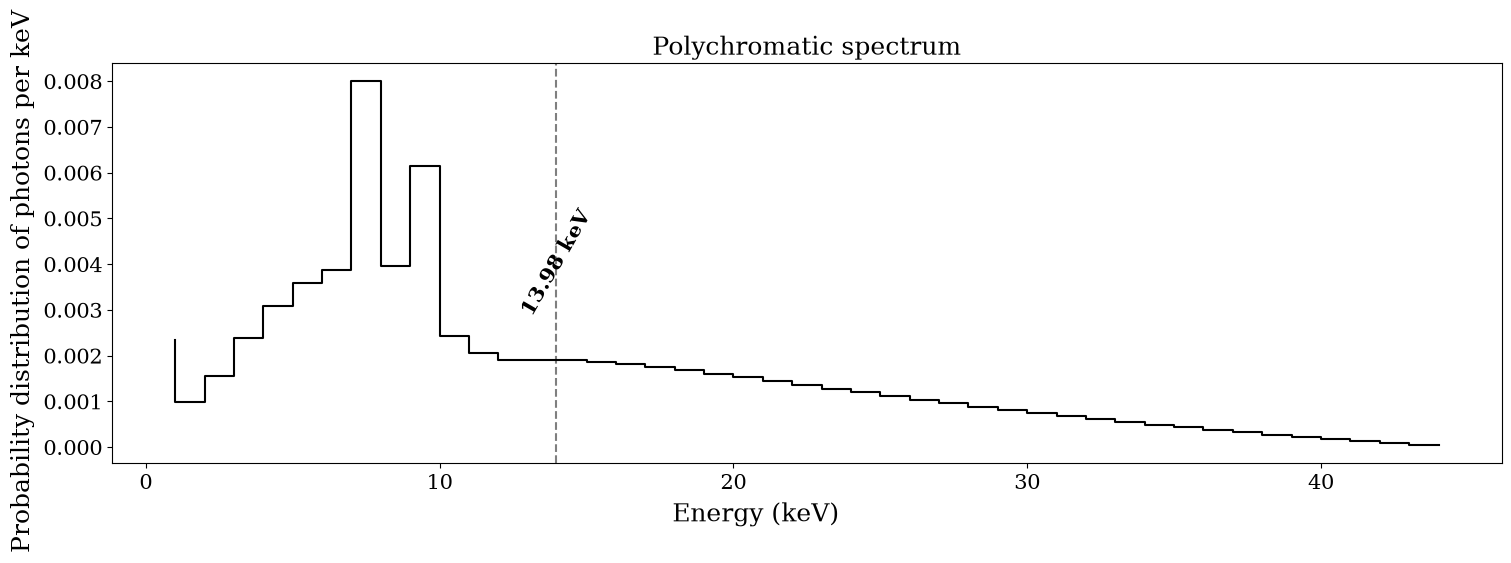

In [ ]:
# ----------
# No filter
# ----------
poly_spectrum_hist = setPolySpectrum(
    tube_voltage_kV,
    filters=None,
    tube_angle_in_deg=tube_angle_degrees,
    mAs=300,
    unit="keV",
)

poly_spectrum_bins, poly_spectrum_photons = zip(*poly_spectrum_hist.items(), strict=False)

fig = plt.figure(figsize= (15,5), constrained_layout=True)
fig.supxlabel("Energy (keV)")
fig.supylabel("Probability distribution of photons per keV")

plt.title(f"Polychromatic spectrum")
plt.step(poly_spectrum_bins, poly_spectrum_photons, "k")

# average_energy = np.average(poly_spectrum_bins, weights=poly_spectrum_photons)
average_energy = np.sum(np.array(poly_spectrum_photons)*np.array(poly_spectrum_bins))/np.sum(poly_spectrum_photons)

plt.axvline(average_energy, linestyle="--", color="k",alpha=0.5)
y_min, y_max = plt.ylim()
y_mid = (y_min + y_max) / 2

plt.text(
    average_energy, y_mid,
    f"{average_energy:.2f} keV",
    rotation=60,
    va="center",
    ha="center",
    fontsize=15,
    fontweight="bold",
)

plt.show()

x_ray_poly_image = np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()

### Create an Aluminium stepwedge as main object source

In [13]:
gvxr.removePolygonMeshesFromSceneGraph()

detector_width, detector_height = gvxr.getDetectorSize("mm")

step_wedge_name = "step-wedge"
step_wedge_length = detector_width * 0.6
step_wedge_width = detector_height * 0.6
step_height = 10
step_wedge_height = step_height * 10
step_wedge_material = "Al"


gvxr.makeStepWedge(
    step_wedge_name,
    10, # Number of steps
    step_wedge_length, step_wedge_width,
    step_height,
    step_height,
    "mm",
)

gvxr.addPolygonMeshAsOuterSurface(step_wedge_name)

gvxr.setElement(
    step_wedge_name,
    step_wedge_material
)

gvxr.rotateNode(
    step_wedge_name,
    90, 0, 90
)

gvxr.translateNode(
    step_wedge_name,
    0, 0, -step_wedge_height * 0.5,
    "mm",
)


### Convert the spectrum to monochromatic of energy similar to average of the polychromatic spectrum

In [14]:
gvxr.setMonoChromatic(average_energy, "keV", 1000)

# Source type
gvxr.usePointSource()

In [15]:
x_ray_mono_image = np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()

In [16]:
plt.figure(figsize=(17, 7.5))

x_ray_L_buffer = np.array(gvxr.getLastLBuffer(), dtype=np.single)

x_ray_mono_image_normalised = x_ray_mono_image / x_ray_mono_image.max()
x_ray_mono_image_normalised[x_ray_mono_image_normalised < 1e-9] = 1e-9
x_ray_mono_image_absorption = -np.log(x_ray_mono_image_normalised)

x_ray_poly_image_normalised = x_ray_poly_image / x_ray_poly_image.max()
x_ray_poly_image_normalised[x_ray_poly_image_normalised < 1e-9] = 1e-9
x_ray_poly_image_absorption = -np.log(x_ray_poly_image_normalised)

plt.subplot(131)
plt.imshow(x_ray_mono_image_absorption, cmap="gray")
plt.colorbar(orientation='vertical')
plt.title(f"{step_wedge_name} projection")

plt.subplot(132)
plt.imshow(x_ray_poly_image_absorption, cmap="gray")
plt.colorbar(orientation='vertical')
plt.title(f"{step_wedge_name} projection")

plt.subplot(133)
plt.imshow(x_ray_L_buffer, cmap="gray")
plt.colorbar(orientation='vertical')
plt.title(f"{step_wedge_name} path lengths")

plt.show()
# TODO: Choose a monochromatic mean energy that most closely matches the poly curve.
# Sort data to interpolate between them.
# Function in numpy that return indices of values that are sorted.
# Sort the for path length vs intensity so you actually get a monotonically
# Index must be on the minus log

# indices = np.argsort(x)
# plt.plot(x[indices], f[indices], '-bo', ms = 2)

lookup_table_indices = np.argsort(np.ravel(x_ray_poly_image_absorption))

plt.figure(figsize=(17, 7.5))

plt.plot(
    np.ravel(x_ray_L_buffer)[lookup_table_indices],
    np.ravel(x_ray_mono_image_absorption)[lookup_table_indices],
)
plt.plot(
    np.ravel(x_ray_L_buffer)[lookup_table_indices],
    np.ravel(x_ray_poly_image_absorption)[lookup_table_indices],
)

plt.title("Absorption vs Path length comparison")
plt.xlabel("Path lengths ox X-rays (mm)")
plt.ylabel("-log(I/I_0)")
plt.show()

# After the BHC, it changes from relative LAC

ValueError: zero-size array to reduction operation maximum which has no identity

<Figure size 1700x750 with 0 Axes>